Rodrigo Melero Moreno (100522305) y Lidia Blanco García (100522209) - Grupo 5 - Práctica 1
---


# Configuración y carga de datos
Empezamos cargando los datos y fijando la semilla usando el NIA de uno de nosotros para que los resultados sean reproducibles tal y como indica el enunciado.

In [103]:
import numpy as np
import pandas as pd

# Fijamos semilla
SEMILLA = 100522305
np.random.seed(SEMILLA)

# Usamos la suma de los 2 últimos números del NIA usado en la semilla para los datos
# 0 + 5 = 05
bank_df = pd.read_pickle("bank_05.pkl")
competition_df = pd.read_pickle("bank_competition_05.pkl")


# EDA Simplificado

## Comprobación de datos

Primero visualizamos los datos que hemos subido con .head(), así como sus columnas con .columns y datos varios con .describe()

In [104]:
bank_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [105]:
bank_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,None,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,None,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [106]:
bank_df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.00000,11000.000000,11000.000000
mean,41.252727,1529.139273,15.660818,372.524909,2.50800,51.308636,0.828000
std,11.940474,3217.396248,8.417970,347.515713,2.72221,108.782842,2.282936
min,18.000000,-6847.000000,1.000000,2.000000,1.00000,-1.000000,0.000000
25%,32.000000,122.750000,8.000000,138.000000,1.00000,-1.000000,0.000000
50%,39.000000,549.500000,15.000000,255.000000,2.00000,-1.000000,0.000000
75%,49.000000,1711.000000,22.000000,498.000000,3.00000,20.250000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.00000,854.000000,58.000000


Ahora determinaremos el número de variables e instancias, así como el tipo (numéricas o categóricas) de las mismas variables.

In [107]:
instancias, variables = bank_df.shape
print(f"El dataset contiene {instancias} instancias (filas) y {variables} variables (columnas).\n")

# Seleccionamos las numéricas
num_cols = bank_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Seleccionamos las categóricas
cat_cols = bank_df.select_dtypes(include=['object', 'category']).columns.tolist()

print(len(num_cols), "variables numéricas:\n", num_cols)
print(len(cat_cols), "variables categóricas:\n", cat_cols)

El dataset contiene 11000 instancias (filas) y 17 variables (columnas).

7 variables numéricas:
 ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
10 variables categóricas:
 ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']


Ahora, habiendo separado entre variables categóricas y numéricas, visualizaremos con un diagrama de barras de cada variable.

- Categóricas:

In [108]:
import matplotlib.pyplot as plt
def bar_plot(variable):
    """
        input: variable ex: "job"
        output: bar plot & value count
    """
    # get feature
    var = bank_df[variable]
    # count number of categorical variable(value/sample)
    varValue = var.value_counts()

    # visualize
    plt.figure(figsize = (9,3))
    plt.bar(varValue.index, varValue)
    plt.xticks(varValue.index, varValue.index.values)
    plt.ylabel("Frequency")
    plt.title(variable)
    plt.show()
    print("{}: \n {}".format(variable,varValue))

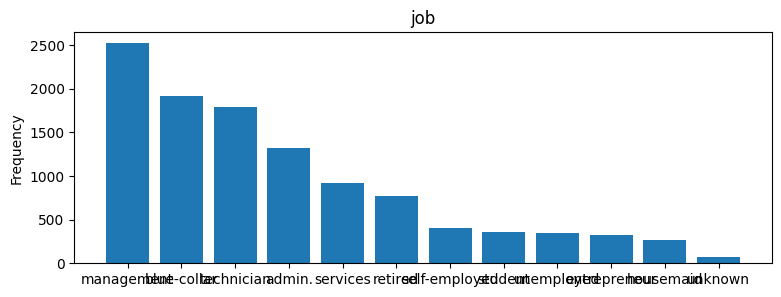

job: 
 job
management       2520
blue-collar      1917
technician       1791
admin.           1317
services          916
retired           774
self-employed     399
student           359
unemployed        347
entrepreneur      322
housemaid         270
unknown            68
Name: count, dtype: int64


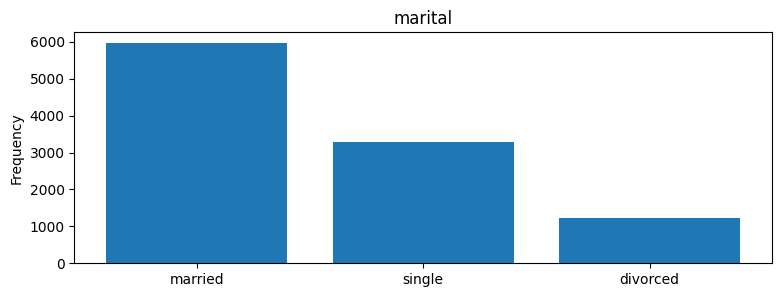

marital: 
 marital
married     5960
single      3292
divorced    1216
Name: count, dtype: int64


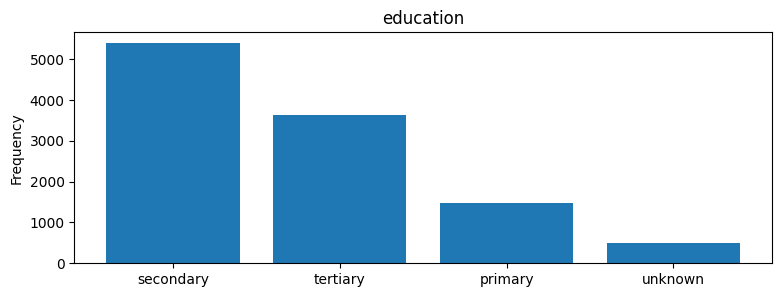

education: 
 education
secondary    5393
tertiary     3630
primary      1483
unknown       494
Name: count, dtype: int64


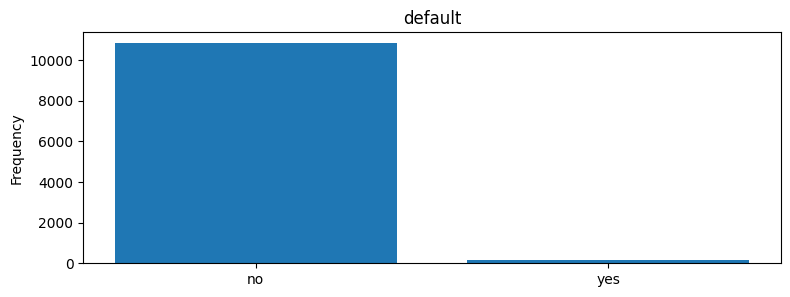

default: 
 default
no     10833
yes      167
Name: count, dtype: int64


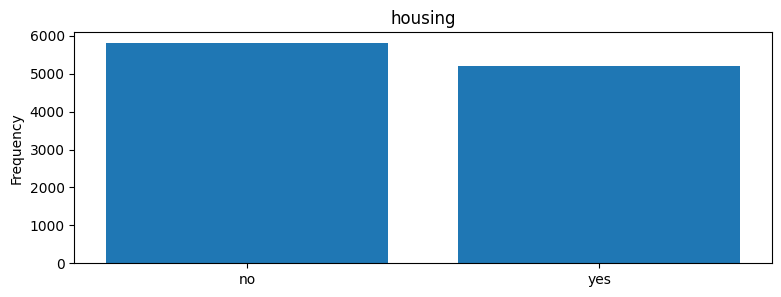

housing: 
 housing
no     5801
yes    5199
Name: count, dtype: int64


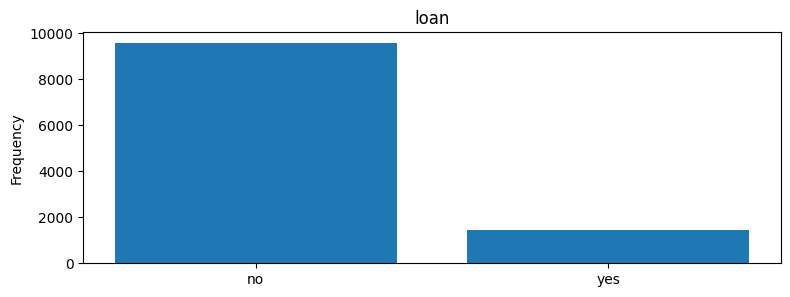

loan: 
 loan
no     9569
yes    1431
Name: count, dtype: int64


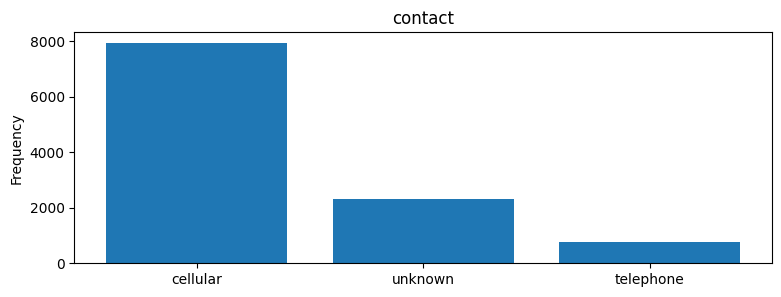

contact: 
 contact
cellular     7922
unknown      2309
telephone     769
Name: count, dtype: int64


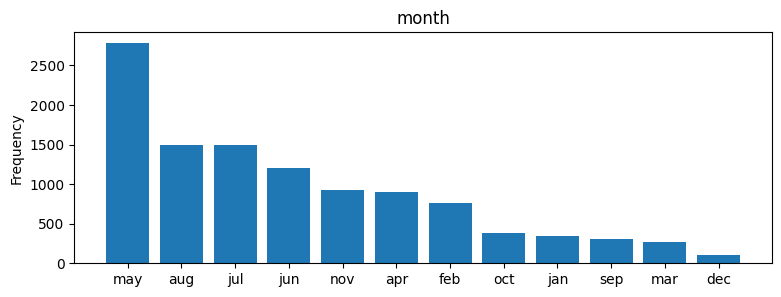

month: 
 month
may    2780
aug    1500
jul    1495
jun    1205
nov     930
apr     905
feb     763
oct     387
jan     342
sep     313
mar     271
dec     109
Name: count, dtype: int64


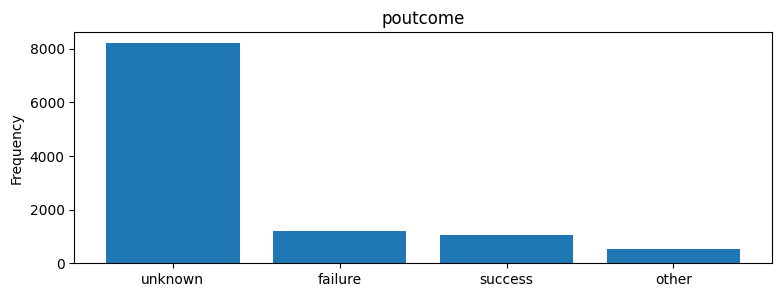

poutcome: 
 poutcome
unknown    8205
failure    1208
success    1059
other       528
Name: count, dtype: int64


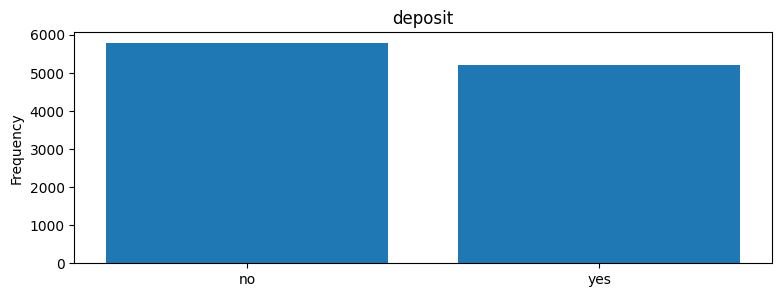

deposit: 
 deposit
no     5780
yes    5220
Name: count, dtype: int64


In [109]:
category = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']
for c in category:
    bar_plot(c)

- Numéricas:

In [110]:
def plot_hist(variable):
    plt.figure(figsize = (9,3))
    plt.hist(bank_df[variable], bins = 50)
    plt.xlabel(variable)
    plt.ylabel("Frequency")
    plt.title("{} distribution with hist".format(variable))
    plt.show()

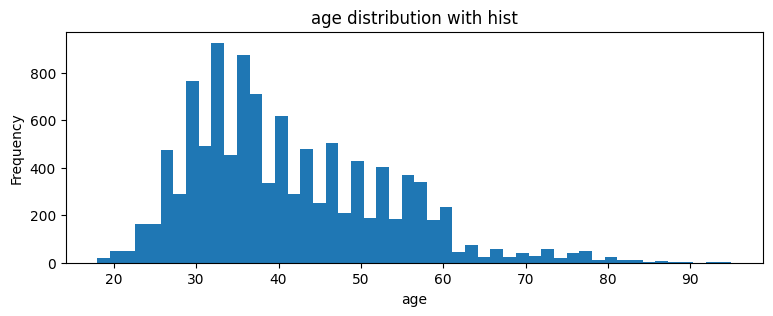

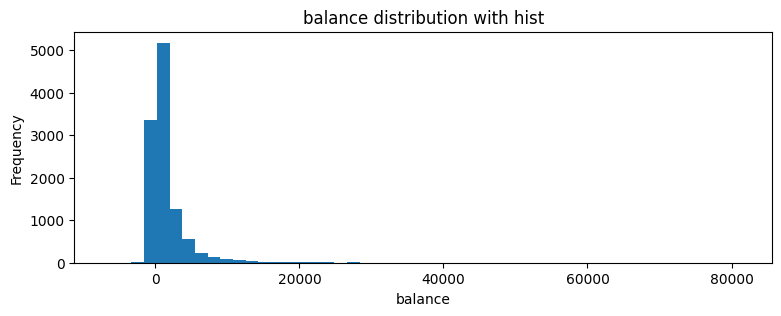

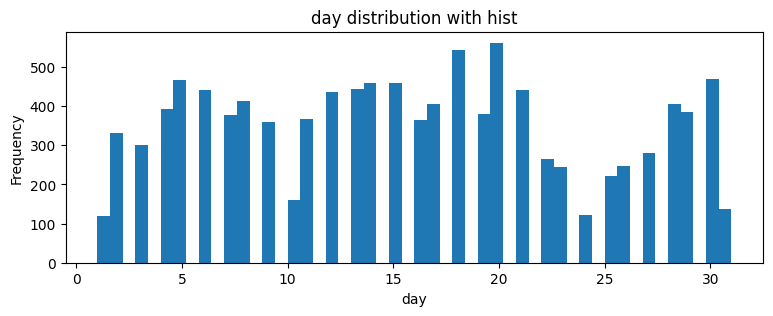

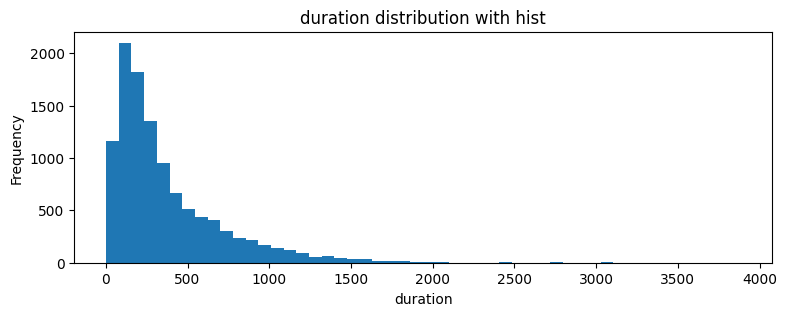

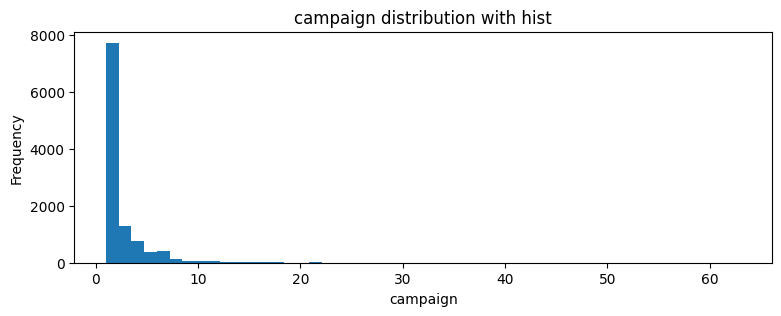

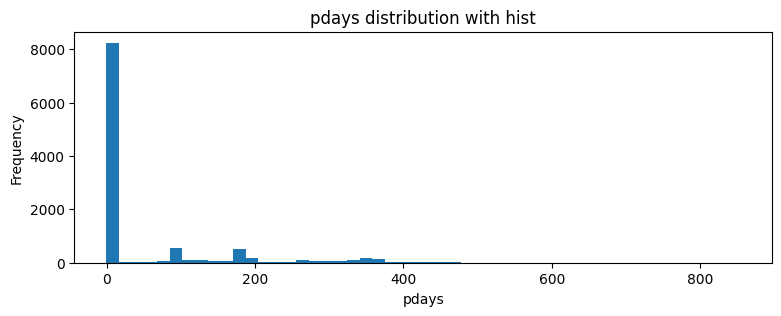

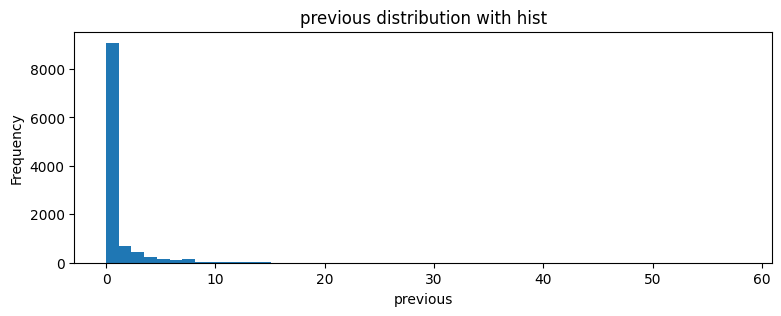

In [111]:
numericVar = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
for n in numericVar:
    plot_hist(n)



---

##Cardinalidad y valores nulos


Comprobamos si hay variables categóricas con alta cardinalidad (>10 valores únicos):

In [112]:
#Comprobamos alta cardinalidad
print("Variables categóricas con alta cardinalidad:")
alta_card = [col for col in cat_cols if bank_df[col].nunique() > 10]
for col in alta_card:
    print(f"- {col}: {bank_df[col].nunique()} valores únicos")

#Comprobamos variables con valores nulos:

print("Valores faltantes por variable:")
nulos = bank_df.isnull().sum()
nulos_filtrados = nulos[nulos > 0]

if not nulos_filtrados.empty:
    print(nulos_filtrados)
else:
    print("- No se han detectado valores nulos (NaN) iniciales en el dataset.")

Variables categóricas con alta cardinalidad:
- job: 12 valores únicos
- month: 12 valores únicos
Valores faltantes por variable:
marital    532
dtype: int64


##Columnas constantes y de ID

Comprobamos si existe alguna columna que tenga un único valor para todas las filas (constante) o que tenga un valor distinto por cada fila (ID)

In [113]:
print("Columnas constantes o IDs:\n")

cols_constantes = [col for col in bank_df.columns if bank_df[col].nunique() == 1]
cols_id = [col for col in bank_df.columns if bank_df[col].nunique() == instancias]

print(f"Columnas constantes encontradas: {cols_constantes if cols_constantes else 'Ninguna'}")
print(f"Columnas tipo ID encontradas: {cols_id if cols_id else 'Ninguna'}")

Columnas constantes o IDs:

Columnas constantes encontradas: Ninguna
Columnas tipo ID encontradas: Ninguna


##Tipo de problema

Como la variable objetivo 'deposit' representa si el cliente contrató o no un depósito, se trata de un problema de clasificación.

Ahora comprobamos si está o no desbalanceado:

Distribución de clases (%):
deposit
no     52.545455
yes    47.454545
Name: proportion, dtype: float64


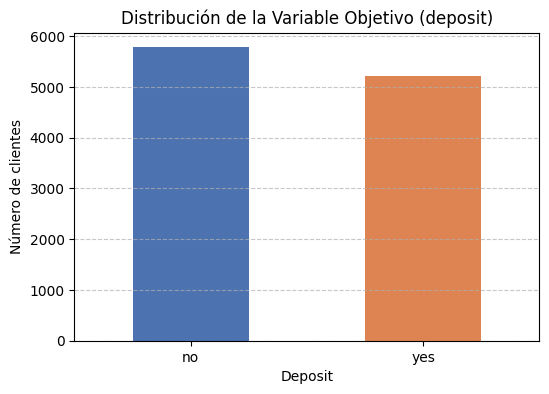

In [114]:
##Comprobamos el balanceo
distribucion_target = bank_df['deposit'].value_counts(normalize=True) * 100
print("Distribución de clases (%):")
print(distribucion_target)
#Hacemos un gráfico de barras
plt.figure(figsize=(6, 4))
ax = bank_df["deposit"].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title("Distribución de la Variable Objetivo (deposit)")
plt.xlabel("Deposit")
plt.ylabel("Número de clientes")
plt.xticks(rotation=0) # Para que las etiquetas del eje X se lean en horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Como podemos apreciar, el problema esta correctamente balanceado, habiendo poca diferencia entre los 2 tipos de valores 'deposit'.

##Estudio de pdays

En el enunciado nos indican que 'pdays' puede valer -1 en caso de que no haya habido contacto, lo que puede ocasionar problemas a la hora de estudiarla.

Primero revisamos cuantos 'pdays' tienen valor -1.

In [115]:
total = (bank_df['pdays'] == -1).sum()
porcentaje = (total / len(bank_df)) * 100

print(f"Clientes con pdays = -1: \n{total} ({porcentaje:.2f}%)")


Clientes con pdays = -1: 
8203 (74.57%)


Descubrimos así que una gran parte de las instancias tienen valor -1 en su atributo 'pdays'. Este -1 supone un problema para ciertos algoritmos como KNN y para distintos métodos de escalado, es por eso que debemos tratarlo en el preprocesado.

Para esto, decidimos añadir un nuevo atributo 'contactado', el cual será un booleano que nos indicará si tenemos datos del último contacto con el cliente en la campaña anterior o no. De tenerlo (es decir, pdays original =! -1) su valor 'pdays' no cambiará, pero de no tener datos de su último contacto, sustituiremos su valor por uno nuevo fuera de rango. Con el fin de definir este 'valor fuera de rango', primero comprobaremos cual es el valor máximo que tiene 'pdays' y le sumaremos una cantidad sustancial para alejarlo del mismo.

In [116]:
print(bank_df['pdays'].max())

854


Descubriendo que el valor máximo es 854, decidimos definir el 'valor fuera de rango' para los clientes sin información de último contacto en 1200.

Estos cambios se realizarán más adelante junto con el resto de preprocesado que se requiera. Esto debido a que como bien sabemos, no debemos involucrar a los datos de 'test' en el mismo, por lo que primero separaremos los datos y luego aplicaremos el preprocesado con el conjunto de 'train' antes de la fase de entrenamiento.

#Decisiones sobre la evaluación


## Metrica adecuada para el problema
Realizaremos la evaluación de nuestro modelo mediante Holdout, es decir dividiremos nuestros datos en train y test, de forma que podamos entrenar a nuestro modelo con parte de los datos y comprobar con los datos faltantes si este es capaz de generalizar pudiendo así estimar su rendimiento a futuro. Dado que el problema al que estamos tratando de darle solución se trata de un problema de clasificación y nuestra variable objeto está balanceada evaluaremos nuestro modelo según su "Accurracy" es decir según su tasa de aciertos en el test. (No se si sería buena idea usar validación cruzada)

##División de los datos en train y test


In [117]:
from sklearn.model_selection import train_test_split

# Creo una base de datos sin la variable objetivo (representa los features)
x = bank_df.drop("deposit", axis=1)

# Creo una base de datos usando únicamente la variable objetivo (representa el target)
y = bank_df["deposit"]

#Compruebo el número de datos de mis nuevas bases de datos
print(x.shape, y.shape)

# Realizo la división de mis datos en train y test con las nuevas bases de datos x e y
# x_train e y_train los utilizará el modelo para aprender (el 67% de los datos)
# x_test e y_test los utilizaremos para evaluar nuestro modelo (el 33% de los datos)
# Al ser una selección aleatoria usaremos una semilla que nos permita poder volver a reproducir nuestros resultados(random_state = SEMILLA)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.33, random_state = SEMILLA)

# Compruebo que se han seleccionado aproximadamente un 67% de los datos
print(x_train.shape, y_train.shape)

(11000, 16) (11000,)
(7370, 16) (7370,)


##Evaluación interna
Para realizar la evaluación interna (inner) necesaria para el ajuste de hiperparámetros volveremos a dividir nuestro conjunto de datos en train y en test de manera que podamos probar con distintos valores para los hiperparametros y determinar cual es el mejor valor. Para esta evaluación interna utilizaremos 5-fold crossvalidation, es decir, partiremos nuestro conjunto inicial train en 5 conjuntos independientes que iteraremos para evaluar siendo la media de los resultados nuestra tasa de aciertos.

# Métodos básicos: KNN y Trees


##Preprocesado

Habiendo separado correctamente los conjuntos de 'train' y 'test', comenzamos con el preprocesado aplicándolo solo al conjunto 'train'.

###Tratamiento de pdays

Aplicamos el preprocesado para el atributo pdays siguiendo los pasos que definimos anteriormente.

In [118]:
# Creamos la columna 'contactado': 0 si pdays es -1, y 1 en caso contrario
x_train['contactado'] = np.where(x_train['pdays'] == -1, 0, 1)

# Definimos el valor fuera de rango
valor_fuera_rango = 1200

# Cambiamos las instancias con pdays = -1
x_train['pdays'] = np.where(x_train['pdays'] == -1, valor_fuera_rango, x_train['pdays'])

###Método de escalado más apropiado


Para elegir el método de escalador realizaremos una evaluación con nuestro conjunto de train, probando los distintos escaladores con 5-fold crossvalidation, posteriormente elegiremos el mejor de los resultados.

Para ello, definiremos una función evaluar_resultado que, además de crear el pipeline usando KNN, haga uso de la 'ColumnTransformer' para tratar con OneHotEncoder los atributos categóricos.

In [119]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline

# Redefinimos 'category' sin deposit
category.remove("deposit")

# Definimos función para los escaladores
def evaluar_escalador(scaler_elegido):
    preprocesador = ColumnTransformer(
        transformers=[
            ('num', scaler_elegido, numericVar),
            ('cat', OneHotEncoder(handle_unknown='ignore'), category)
        ])

    # Usamos pipelines para el preprocesado con KNN
    pipeline = Pipeline(steps=[
        ('preprocesador', preprocesador),
        ('knn', KNeighborsClassifier())
    ])

    return pipeline

#Establecemos las particiones de nuestro conjunto train
kf = KFold(n_splits=5, shuffle = True, random_state = SEMILLA)

#Comprobamos con MinMax
pipeline_min_max = evaluar_escalador(MinMaxScaler())
min_max_puntuacion = cross_val_score(pipeline_min_max, x_train, y_train, cv=kf, scoring='accuracy')

print("Resultado del escalado con min_max: ", min_max_puntuacion.mean())

#Comprobamos con Escalado
pipeline_standard = evaluar_escalador(StandardScaler())
standard_puntuacion = cross_val_score(pipeline_standard, x_train, y_train, cv=kf, scoring='accuracy')

print("Resultado del escalado con standard: ", standard_puntuacion.mean())

#Comprobamos con Robust
pipeline_robust = evaluar_escalador(RobustScaler())
robust_puntuacion = cross_val_score(pipeline_robust, x_train, y_train, cv=kf, scoring='accuracy')

print("Resultado del escalado con robust: ", robust_puntuacion.mean())

Resultado del escalado con min_max:  0.739620081411126
Resultado del escalado con standard:  0.7960651289009497
Resultado del escalado con robust:  0.7864314789687924


El mejor escalador es Standard, por lo que será el que usaremos cuando se requiera próximamente.


#Modelos básicos
Para empezar, evaluaremos unos modelos simples: KNN y árboles de decisión.

La evaluación se realizará primero con sus hiperparámetros por omisión y más adelante se procederá a ajustarlos mediante GridSearch.


##KNN


###Hiperparámetros por omisión
Primeramente evaluaremos con KNN con sus hiperparámetros por omisión y mediremos el tiempo que tarda el entrenamiento

In [120]:
import time

# Creamos el preprocesador con nuestro mejor escalador
preprocesador_definitivo = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numericVar),
        ('cat', OneHotEncoder(handle_unknown='ignore'), category)
    ])

# Usamos un pipeline para evitar data leackage
pipe_knn_final = Pipeline([
    ('preprocesador', preprocesador_definitivo),
    ('knn', KNeighborsClassifier())] #Al no meter ningún parámetro estaremos realizando la evaluación con sus hiperparámetros por omisión
)

# Evaluamos tal y como dijimos que realizaríamos la inner evaluation (con 5-fold crossvalidation)
resultados_cv = cross_val_score(pipe_knn_final, x_train, y_train, cv=kf, scoring='accuracy')

print("Resultado KNN con hiperparámetros por omisión: ", resultados_cv.mean())

inicio = time.time()
pipe_knn_final.fit(x_train, y_train)
fin = time.time()

print("Tiempo de entrenamiento knn: ", fin - inicio)

Resultado KNN con hiperparámetros por omisión:  0.7960651289009497
Tiempo de entrenamiento knn:  0.02771902084350586


###Hiperparámetros ajustados
A continuación ajustaremos los hiperparámetros de KNN (número de vecinos, pesos y distancias) mediante una búsqueda con GridSearch

In [121]:
from sklearn.model_selection import GridSearchCV
# Cambiamos las variables target a binario para evitar errores
y_train_num = y_train.map({'no': 0, 'yes': 1})
y_test_num = y_test.map({'no': 0, 'yes': 1})

# Definimos ahora los hiperparámetros de KNN (que será la rejilla de parámetros)
parametros_grid = {
    'knn__n_neighbors': [2, 4, 8, 16, 32],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2] # siendo 1 Manhattan y 2 Euclidiana
}

# Definimos nuestro GridSearch
buscador_grid_knn = GridSearchCV(pipe_knn_final,
                             param_grid=parametros_grid,
                             cv=kf,
                             scoring='accuracy',
                             n_jobs=-1,
                             return_train_score=True
)

inicio = time.time()
buscador_grid_knn.fit(x_train, y_train_num)
fin = time.time()

print("Mejor configuración encontrada: ", buscador_grid_knn.best_params_)
print("Mejor puntuación encontrada: ", buscador_grid_knn.best_score_)
print("Tiempo de ejecución: ", fin - inicio)


Mejor configuración encontrada:  {'knn__n_neighbors': 16, 'knn__p': 2, 'knn__weights': 'distance'}
Mejor puntuación encontrada:  0.808683853459973
Tiempo de ejecución:  175.4373598098755


###Efecto hiperparámetros
Para ver el efecto de los distintos valores de los hiperparámetros elegiremos uno para evaluar, fijaremos el resto de hiperparámetros con sus mejores valores y variaremos el valor del que estamos evaluando para comprobar que efecto tiene.

####N-neighbors

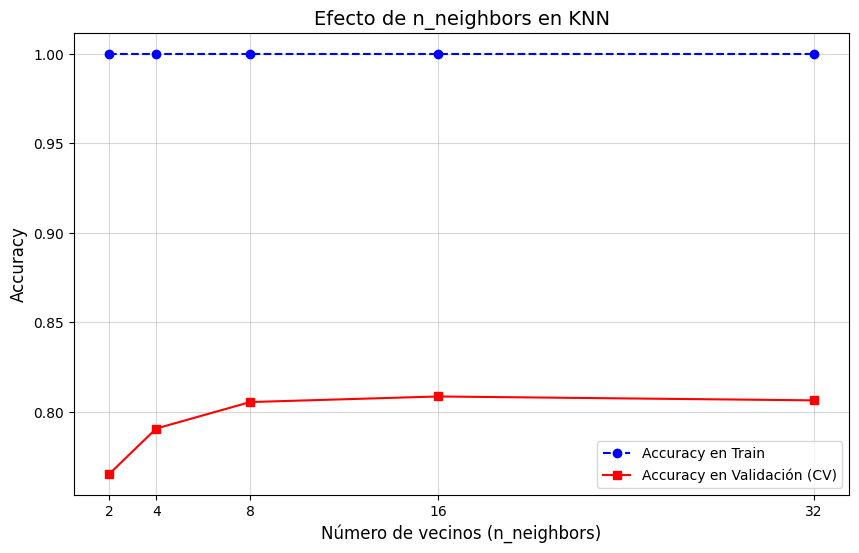

In [122]:
# Convertimos diccionario de resultados en un DataFrame de pandas
resultados_knn = pd.DataFrame(buscador_grid_knn.cv_results_)

# Extraemos los mejores valores para 'weights' y 'p'
mejor_weight = buscador_grid_knn.best_params_['knn__weights']
mejor_p = buscador_grid_knn.best_params_['knn__p']

# Filtramos el DataFrame para dejar fijos esos mejores valores y aislar n_neighbors
datos_knn_plot = resultados_knn[
    (resultados_knn['param_knn__weights'] == mejor_weight) &
    (resultados_knn['param_knn__p'] == mejor_p)
].sort_values('param_knn__n_neighbors')

# Extraemos los datos para los ejes X e Y
vecinos = datos_knn_plot['param_knn__n_neighbors']
train_scores_knn = datos_knn_plot['mean_train_score']
cv_scores_knn = datos_knn_plot['mean_test_score']

# Generamos el gráfico
plt.figure(figsize=(10, 6))
plt.plot(vecinos, train_scores_knn, marker='o', linestyle='--', color='blue', label='Accuracy en Train')
plt.plot(vecinos, cv_scores_knn, marker='s', linestyle='-', color='red', label='Accuracy en Validación (CV)')

plt.title("Efecto de n_neighbors en KNN", fontsize=14)
plt.xlabel("Número de vecinos (n_neighbors)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(vecinos)
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

Lo primero que observamos es que el accuracy cuando evaluamos con nuestro conjunto 'train', se mantiene constante en 1 sea cual sea el valor de 'n'. Esto se produce porque estamos usando el 'distance' para el hiperparámetro 'weight', por lo que al momento de añadir un punto, la distancia que más influye es la suya misma sí mismo, es decir, 0, por lo que se ha memorizado a si mismo y siempre acertará. Esto ocurrirá de nuevo cuando evaluemos el hiperparámetro 'p'.

Podemos observar como, con un valor 'n' muy bajo, se produce 'overfitting', ya que el accuracy con los datos de entrenamiento se mantiene en 1 pero al evaluarse con datos nuevos tiene una puntuación muy baja, lo que nos indica que el modelo está memorizando el ruido y por ello mismo se obtienen estos resultados.

Observamos desde ahí un aumento del accuracy según aumentamos a su vez 'n', llegando a su pico con n=16 y volviendo a bajar levemente con n=32, lo que puede indicar primeros indicios de 'underfitting', ya que el modelo se vuelve demasiado genérico y pierde precisión.

####Weights


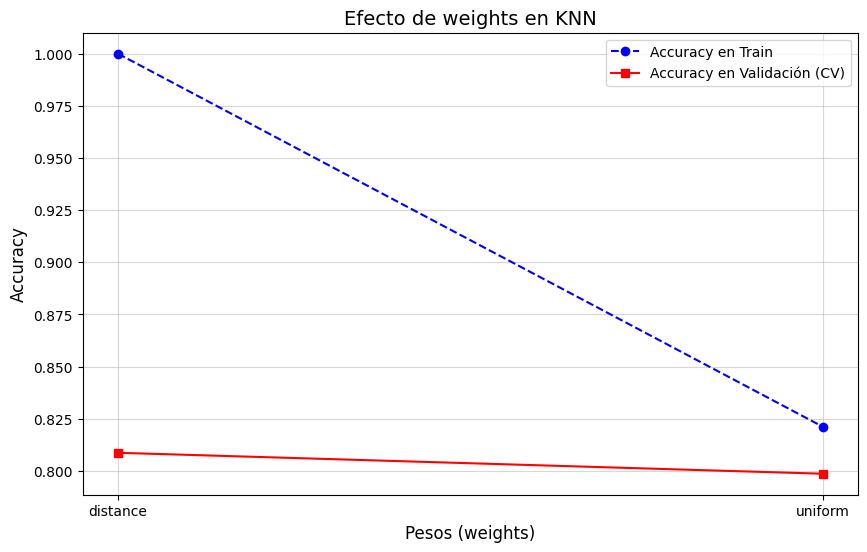

In [123]:
# Extraemos el mejor valor para n_neighbors (mejor_p ya lo calculaste antes)
mejor_n_neighbors = buscador_grid_knn.best_params_['knn__n_neighbors']

# Filtramos el DataFrame dejando fijos n_neighbors y p
datos_knn_weights = resultados_knn[
    (resultados_knn['param_knn__n_neighbors'] == mejor_n_neighbors) &
    (resultados_knn['param_knn__p'] == mejor_p)
].sort_values('param_knn__weights')

# Extraemos los datos
pesos = datos_knn_weights['param_knn__weights']
train_scores_weights = datos_knn_weights['mean_train_score']
cv_scores_weights = datos_knn_weights['mean_test_score']

# Generamos el gráfico
plt.figure(figsize=(10, 6))
plt.plot(pesos, train_scores_weights, marker='o', linestyle='--', color='blue', label='Accuracy en Train')
plt.plot(pesos, cv_scores_weights, marker='s', linestyle='-', color='red', label='Accuracy en Validación (CV)')

plt.title("Efecto de weights en KNN", fontsize=14)
plt.xlabel("Pesos (weights)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
# No ponemos xticks aquí porque 'pesos' son strings ('uniform', 'distance') y matplotlib lo autoajusta
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

Aquí, lo primero que observamos es que, al tomar weights=uniform, se rompe esa accuracy irreal de 1 con los datos de entrenamiento, tomando un valor más realista.

Por otra parte, se puede apreciar cómo, evaluándolo ya sea con los conjuntos de train o los de validación, 'distance' obtiene un mejor resultado que 'uniform' en todos los casos.

####P

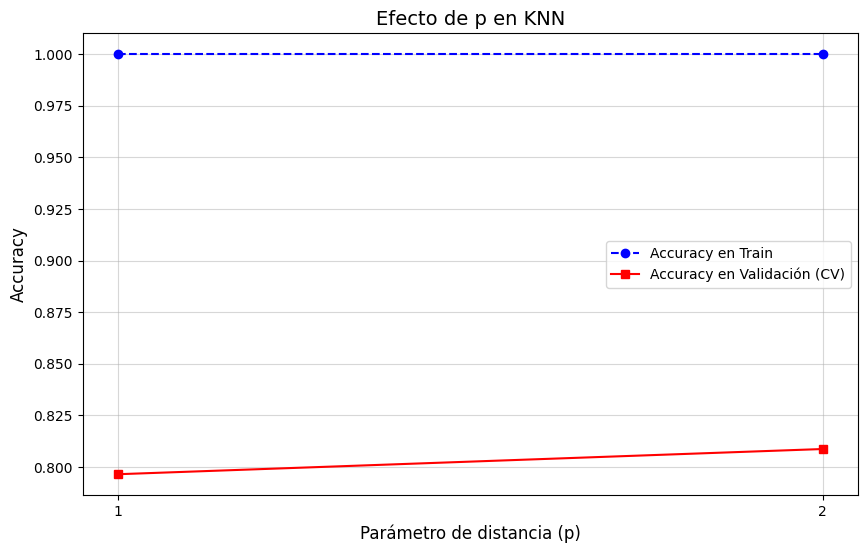

In [124]:
# Filtramos el DataFrame dejando fijos n_neighbors y weights
datos_knn_p = resultados_knn[
    (resultados_knn['param_knn__n_neighbors'] == mejor_n_neighbors) &
    (resultados_knn['param_knn__weights'] == mejor_weight)
].sort_values('param_knn__p')

# Extraemos los datos
distancias = datos_knn_p['param_knn__p']
train_scores_p = datos_knn_p['mean_train_score']
cv_scores_p = datos_knn_p['mean_test_score']

# Generamos el gráfico
plt.figure(figsize=(10, 6))
plt.plot(distancias, train_scores_p, marker='o', linestyle='--', color='blue', label='Accuracy en Train')
plt.plot(distancias, cv_scores_p, marker='s', linestyle='-', color='red', label='Accuracy en Validación (CV)')

plt.title("Efecto de p en KNN", fontsize=14)
plt.xlabel("Parámetro de distancia (p)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(distancias)
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

Como dedujimos anteriormente, el accuracy en train se mantiene constante en 1.

Por otra parte, el accuracy en validación nos revela que el uso de p=2 (distancia Euclidiana) es mejor para nuestro modelo

###Conclusión
Tras analizar el ajuste de los hiperparámetros de KNN, observamos que el modelo sufre de un fuerte sobreajuste en la fase de entrenamiento al elegir el hiperparámetro weights='distance'. Sin embargo, esta configuración (junto con N=16 vecinos y la métrica de distancia Euclidiana p=2) es la que logra la mejor capacidad de generalización en datos no vistos.

## Árboles de decisión

###Hiperparámetros por omision
Evaluamos con árboles de decisión usando sus hiperparámetros por omisión y mediremos el tiempo que tarda el entrenamiento.

In [125]:
import time
from sklearn import tree

# Creamos un preprocesador especial para árboles que solo haga el OneHotEncoder ya que lo árboles
# no rquieres de un escalado
preprocesador_arboles = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), category)
    ])

# Creamos la Pipeline con hiperparámetros por omisión
pipe_arbol = Pipeline([
    ('preprocesador', preprocesador_arboles),
    ('arbol', tree.DecisionTreeClassifier(random_state=SEMILLA))
])

# Evaluamos tal y como dijimos que realizaríamos la inner evaluation (con 5-fold crossvalidation)
resultados_cv_arbol = cross_val_score(pipe_arbol, x_train, y_train, cv=kf, scoring='accuracy')

print("Resultado Árbol con hiperparámetros por omisión: ", resultados_cv_arbol.mean())

inicio_arbol = time.time()
pipe_arbol.fit(x_train, y_train)
fin_arbol = time.time()

print("Tiempo de entrenamiento de árboles: ", fin_arbol - inicio_arbol)

Resultado Árbol con hiperparámetros por omisión:  0.6853459972862957
Tiempo de entrenamiento de árboles:  0.13373565673828125


### Interpretación de árbol
Usaremos árboles poco profundos para obtener una interpretación sobre cómo se pueden llevar a cabo decisiones en este problema.

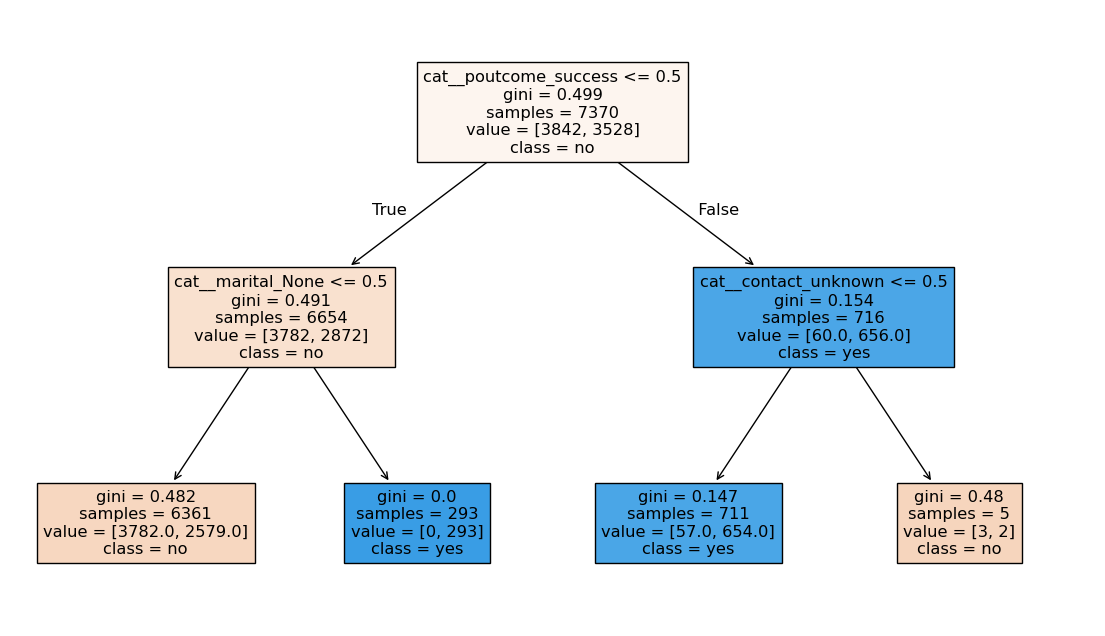

In [126]:
pipe_limitado = Pipeline([
    ('preprocesador', preprocesador_arboles),
    ('arbol', tree.DecisionTreeClassifier(max_depth=2, random_state=SEMILLA))
])

pipe_limitado.fit(x_train, y_train) # Entrenamos el modelo limitando la profundidad máxima para crear árboles poco profundos

modelo_arbol = pipe_limitado.named_steps['arbol']
nombres_columnas = pipe_limitado.named_steps['preprocesador'].get_feature_names_out()

# Dibujamos el árbol
plt.figure(figsize=(14, 8))
tree.plot_tree(
    modelo_arbol,
    feature_names=nombres_columnas,
    class_names=['no', 'yes'],
    filled=True,
)

plt.show()

Al limitar el árbol a una profundidad de 2, podemos extraer la regla principal que determina si un cliente contrata el depósito o no:

- Regla principal: La regla que tiene un mayor peso es 'poutcome' (resultados de la campaña de marketing anterior)

- Rama izquierda: Si el cliente NO contrató nada en la campaña anterior, la probabilidad de que contrate el depósito actual es baja.

- Rama derecha: Si el cliente SÍ contrató un producto en la campaña anterior, es altamente probable que contrate el depósito actual.

Además de esto, vemos que las reglas 'marital' y 'contact' también tienen una importancia a tener en cuenta.

### Hiperparámetros ajustados
A continuación ajustaremos los hiperparámetros de los árboles de decisión (max_depth y min_samples_split).


In [127]:
from sklearn.model_selection import GridSearchCV
import pandas as pd


# Añadimos min_impurity_decrease al espacio de búsqueda
param_grid_arbol = {
    'arbol__max_depth': list(range(2,16,2)),
    'arbol__min_samples_split': list(range(2,16,2)),
    'arbol__min_impurity_decrease': [0.0, 0.001, 0.005, 0.01, 0.02]
}

# Configuramos GridSearchCV (mantenemos tu configuración original)
grid_arbol = GridSearchCV(estimator=pipe_arbol,
                          param_grid=param_grid_arbol,
                          cv=kf,
                          scoring='accuracy',
                          n_jobs=-1,
                          return_train_score=True
)

inicio_arbol = time.time()
grid_arbol.fit(x_train, y_train_num)
fin_arbol = time.time()

# Resultados de tiempo
print("Mejor configuración encontrada: ", grid_arbol.best_params_)
print("Mejor puntuación encontrada: ", grid_arbol.best_score_)
print("Tiempo de ejecución: ", fin_arbol - inicio_arbol)

Mejor configuración encontrada:  {'arbol__max_depth': 14, 'arbol__min_impurity_decrease': 0.001, 'arbol__min_samples_split': 2}
Mejor puntuación encontrada:  0.7271370420624151
Tiempo de ejecución:  82.00666284561157


###Efecto hiperparámetros
Para ver el efecto de los distintos valores de los hiperparámetros elegiremos uno para evaluar, fijaremos el resto de hiperparámetros con sus mejores valores y variaremos el valor del que estamos evaluando para comprobar que efecto tiene.

####Max_depth

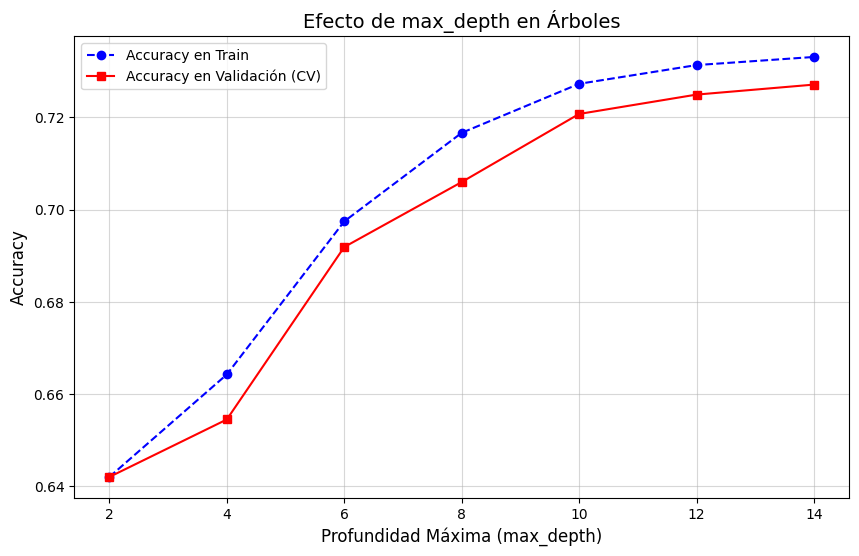

In [128]:
# Convertimos el diccionario de resultados en un DataFrame
resultados_arbol = pd.DataFrame(grid_arbol.cv_results_)

# Extraemos los mejores valores para los otros dos parámetros
mejor_split = grid_arbol.best_params_['arbol__min_samples_split']
mejor_impurity = grid_arbol.best_params_['arbol__min_impurity_decrease']

# Filtramos el DataFrame para dejar fijos esos valores
datos_arbol_plot = resultados_arbol[
    (resultados_arbol['param_arbol__min_samples_split'] == mejor_split) &
    (resultados_arbol['param_arbol__min_impurity_decrease'] == mejor_impurity) &
    (resultados_arbol['param_arbol__max_depth'].notnull()) # Por precaución si pruebas con 'None'
].sort_values('param_arbol__max_depth')

# Extraemos los datos para los ejes
profundidades = datos_arbol_plot['param_arbol__max_depth']
train_scores_arbol = datos_arbol_plot['mean_train_score']
cv_scores_arbol = datos_arbol_plot['mean_test_score']

# Generamos el gráfico
plt.figure(figsize=(10, 6))
plt.plot(profundidades, train_scores_arbol, marker='o', linestyle='--', color='blue', label='Accuracy en Train')
plt.plot(profundidades, cv_scores_arbol, marker='s', linestyle='-', color='red', label='Accuracy en Validación (CV)')

plt.title('Efecto de max_depth en Árboles', fontsize=14)
plt.xlabel('Profundidad Máxima (max_depth)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(profundidades)
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

Podemos apreciar cómo en ambas evaluaciones se produce un crecimiento no lineal del accuracy, llegando a su punto máximo con max_depth=14 y aumentando considerablemtne su precisión hasta en casi un 10% (0,1).

Vemos además cómo el crecimiento, aunque empezo muy acelerado, se fue reduciendo según nos acercábamos a 14, lo que nos indica que nos estábamos acercando cada vez más al mejor valor, decrementando la mejora conforme a esto ocurría, demostrando que el problema requiere un modelo relativamente profundo, pero no infinito, para evitar el sobreajuste

####Min_sample_split

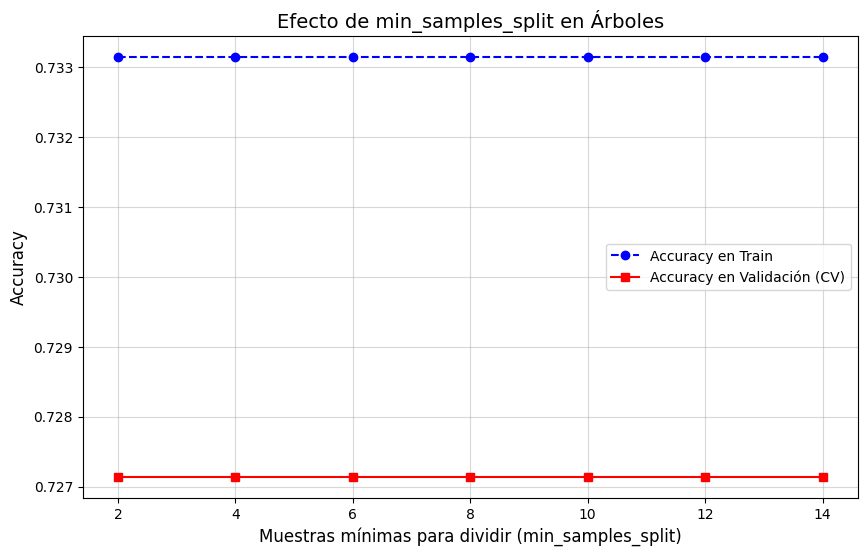

In [129]:
# Extraemos el mejor valor para max_depth (mejor_impurity ya lo calculaste antes)
mejor_depth = grid_arbol.best_params_['arbol__max_depth']

# Filtramos el DataFrame dejando fijos max_depth y min_impurity_decrease
datos_arbol_split = resultados_arbol[
    (resultados_arbol['param_arbol__max_depth'] == mejor_depth) &
    (resultados_arbol['param_arbol__min_impurity_decrease'] == mejor_impurity)
].sort_values('param_arbol__min_samples_split')

# Extraemos los datos
splits = datos_arbol_split['param_arbol__min_samples_split']
train_scores_split = datos_arbol_split['mean_train_score']
cv_scores_split = datos_arbol_split['mean_test_score']

# Generamos el gráfico
plt.figure(figsize=(10, 6))
plt.plot(splits, train_scores_split, marker='o', linestyle='--', color='blue', label='Accuracy en Train')
plt.plot(splits, cv_scores_split, marker='s', linestyle='-', color='red', label='Accuracy en Validación (CV)')

plt.title('Efecto de min_samples_split en Árboles', fontsize=14)
plt.xlabel('Muestras mínimas para dividir (min_samples_split)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(splits)
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

A primera vista podemos observar que el accuracy se mantiene constante sea cual sea el valor de min_samples_split. Esto nos indica que el hiperparámetro está siendo ignorado y no es relevante para el modelo, ya que, cuando se va a dividir, ya sea o bien porque ha llegado a su profundidad máxima (max_depth) o bien por el min_impurity_decrease, es frenado, por lo que el valor asignado a este hiperparámetro no influye en la precisión del modelo.

####Min_impurity_decrease

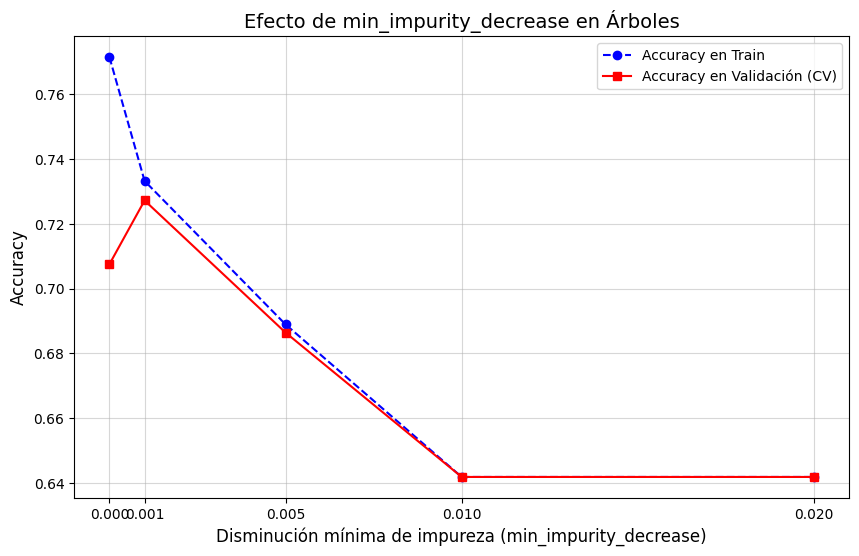

In [130]:
# Filtramos el DataFrame dejando fijos max_depth y min_samples_split
datos_arbol_impurity = resultados_arbol[
    (resultados_arbol['param_arbol__max_depth'] == mejor_depth) &
    (resultados_arbol['param_arbol__min_samples_split'] == mejor_split)
].sort_values('param_arbol__min_impurity_decrease')

# Extraemos los datos
impurezas = datos_arbol_impurity['param_arbol__min_impurity_decrease']
train_scores_impurity = datos_arbol_impurity['mean_train_score']
cv_scores_impurity = datos_arbol_impurity['mean_test_score']

# Generamos el gráfico
plt.figure(figsize=(10, 6))
plt.plot(impurezas, train_scores_impurity, marker='o', linestyle='--', color='blue', label='Accuracy en Train')
plt.plot(impurezas, cv_scores_impurity, marker='s', linestyle='-', color='red', label='Accuracy en Validación (CV)')

plt.title('Efecto de min_impurity_decrease en Árboles', fontsize=14)
plt.xlabel('Disminución mínima de impureza (min_impurity_decrease)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(impurezas)
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

Aquí podemos observar claramente cómo el mejor valor para min_impurity_decrease es 0.001, ya que con min_impurity_decrease=0.00 se produce sobreajuste y con min_impurity_decrease > 0.001 el accuracy baja hasta desplomarse en un accuracy=0.642 aproximadamente.

###Conclusion
Gracias a estas gráficas somos capaces de identificar visualmente y con facilidad el mejor valor de los hiperparámetros 'max_depth' y 'min_impurity_decrease', además de demostrar que 'min_samples_split' no tiene un impacto real sobre el modelo (detalle que se nos habría pasado por alto de no haberlo comprobado de esta manera)

##Conclusiones finales


Antes que nada, para ver cuan bien trabaja nuestro modelo comparado con uno 'dummy', comprobaremos cómo trabaja este último.

In [131]:
from sklearn.dummy import DummyClassifier

# Entrenamos el modelo trivial que predice la clase más frecuente
dummy = DummyClassifier(strategy='most_frequent', random_state=SEMILLA)
# Usamos los mismos datos y particiones (kf) que usamos para el resto
resultados_dummy = cross_val_score(dummy, x_train, y_train, cv=kf, scoring='accuracy')

print("Accuracy del modelo trivial (Dummy): ", resultados_dummy.mean())

Accuracy del modelo trivial (Dummy):  0.5213025780189959


- ¿Los resultados son mejores que los modelos triviales/naive/dummy?

Sí, el modelo trivial (DummyClassifier) obtiene un accuracy de 0.5213, limitándose a predecir la clase mayoritaria. Tanto nuestro mejor modelo KNN (0.8086) como nuestro mejor Árbol de Decisión (0.7271) superan ampliamente este resultado, demostrando que ambos algoritmos son capaces de encontrar patrones reales y obtener una mejor precisión.


- ¿Cuál es el mejor método? ¿A qué coste computacional?

En términos de precisión (accuracy de validación), KNN ha demostrado ser superior, alcanzando (aproximadamente) un 81% frente al 73% de los árboles de decisión. Sin embargo, el coste computacional es distinto por la propia naturaleza de los algoritmos. Los árboles de decisión tienen un coste de entrenamiento mayor pero sus predicciones son casi instantáneas. KNN, por otra parte, entrena rápido pero sufre un coste computacional mucho más elevado en la fase de predicción, ya que debe calcular las distancias (euclidianas en nuestro caso) de cada punto de entrenamiento cada vez que llega un cliente nuevo.


- ¿El ajuste de hiperparámetros mejora con respecto a los valores por omisión?

Sí. Aunque en ocasiones el accuracy global pueda parecer similar o subir ligeramente respecto al valor por defecto (omisión), la verdadera mejora reside en el control del sobreajuste (overfitting) que pudimos apreciar que puede ocurrir con distintos valores de los hiperparámetros. El ajuste de hiperparámetros nos ha permitido encontrar el punto exacto de equilibrio que garantiza que el modelo generalice bien ante datos no vistos.


- ¿Si hay mejora, es el coste computacional elevado?

Sí, el coste computacional del ajuste de hiperparámetros (HPO) es significativamente elevado. Al utilizar gridsearch con validación cruzada de 5 particiones, hemos obligado al sistema a entrenar y evaluar cientos o miles de modelos distintos (por ejemplo, el GridSearch de árboles tardó más de un minuto de ejecutarse y el de KNN tardó más de 2 minutos). No obstante, consideramos este coste asumible y necesario, ya que es un proceso que solo se realiza una vez durante el desarrollo y nos logra encontrar la configuración óptima.

#Métodos avanzados
Terminada la evaluación de los modelos simples KNN y árboles, empezamos ahora a probar modelos más avanzados como modelos lineales y SVM. Una vez más, primero los evaluaremos con sus hiperparámetros por omisión y más adelantes procederemos con el ajuste de sus hiperparámetros

##Modelos lineales

###Hiperparámetros por omisión
Evaluamos con los hiperparámetros por omisión

In [132]:
from sklearn.linear_model import LogisticRegression

# Creamos primero el pipeline para el modelo lineal sin regularización L1
pipe_lineal_sin = Pipeline([
    ('preprocesador', preprocesador_definitivo), # Seguimos usando el preprocesado anterior con el escalador standard
    ('lineal_sin', LogisticRegression(penalty=None, max_iter=1000, random_state=SEMILLA))
])

res_lineal_none = cross_val_score(pipe_lineal_sin, x_train, y_train_num, cv=kf, scoring='accuracy', n_jobs=-1)

print("Resultado modelo lineal sin L1 e hiperparámetros por omisión: ", res_lineal_none.mean())

inicio = time.time()
pipe_lineal_sin.fit(x_train, y_train_num)
fin = time.time()

print("Tiempo de entrenamiento de modelo lineal sin L1 e hiperparámetros por omisión: ", fin - inicio)

# Evaluamos ahora con regularización L1
pipe_lineal_l1 = Pipeline([
    ('preprocesador', preprocesador_definitivo),
    ('lineal_l1', LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=SEMILLA))
])

res_lineal_l1 = cross_val_score(pipe_lineal_l1, x_train, y_train_num, cv=kf, scoring='accuracy', n_jobs=-1)

print("Resultado modelo lineal con L1 e hiperparámetros por omisión: ", res_lineal_l1.mean())

inicio = time.time()
pipe_lineal_l1.fit(x_train, y_train_num)
fin = time.time()

print("Tiempo de entrenamiento de modelo lineal con L1 e hiperparámetros por omisión: ", fin - inicio)

Resultado modelo lineal sin L1 e hiperparámetros por omisión:  0.83202170963365
Tiempo de entrenamiento de modelo lineal sin L1 e hiperparámetros por omisión:  0.09830546379089355
Resultado modelo lineal con L1 e hiperparámetros por omisión:  0.8328358208955224
Tiempo de entrenamiento de modelo lineal con L1 e hiperparámetros por omisión:  0.13469481468200684


###Hiperparámetros ajustados

In [133]:
# HPO: modelo lineal con L1
param_grid_l1 = {
    'lineal_l1__C': [0.01, 0.1, 1, 10, 100] # Valores a probar
}

grid_lineal_l1 = GridSearchCV(pipe_lineal_l1,
                              param_grid_l1,
                              cv=kf,
                              scoring='accuracy',
                              n_jobs=-1)

inicio = time.time()
grid_lineal_l1.fit(x_train, y_train_num)
fin = time.time()

print("Mejores params L1:", grid_lineal_l1.best_params_)
print("Mejor accuracy L1:", grid_lineal_l1.best_score_)
print(f"Tiempo total HPO L1: {fin - inicio:.2f} s\n")

Mejores params L1: {'lineal_l1__C': 1}
Mejor accuracy L1: 0.8328358208955224
Tiempo total HPO L1: 6.30 s



Curiosamente, el accuracy es el mismo, lo que nos indica que los hiperparámetros seleccionados por el gridsearch son los hiperparámetros que se seleccionan por omisión.

##SVM

###Hiperparámetros por omisión
Evaluamos con los hiperparámetros por omisión

In [134]:
from sklearn.svm import SVC

# Creamos pipeline para SVM
pipe_svm = Pipeline([
    ('preprocesador', preprocesador_definitivo),
    ('svm', SVC(random_state=SEMILLA))
])

res_svm = cross_val_score(pipe_svm, x_train, y_train_num, cv=kf, scoring='accuracy', n_jobs=-1)

print("Resultado SVM con hiperparámetros por omisión: ", res_svm.mean())

inicio = time.time()
pipe_svm.fit(x_train, y_train_num)
fin = time.time()

print("Tiempo de entrenamiento de SVM con hiperparámetros por omisión: ", fin - inicio)

Resultado SVM con hiperparámetros por omisión:  0.8565807327001357
Tiempo de entrenamiento de SVM con hiperparámetros por omisión:  1.4847676753997803


###Hiperparámetros ajustados

In [135]:
param_grid_svm = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto', 0.1, 1]
}

grid_svm = GridSearchCV(pipe_svm, param_grid_svm, cv=kf, scoring='accuracy', n_jobs=-1)

inicio = time.time()
grid_svm.fit(x_train, y_train_num)
fin = time.time()

print("Mejores params SVM:", grid_svm.best_params_)
print("Mejor accuracy SVM:", grid_svm.best_score_)
print(f"Tiempo total HPO SVM: {fin - inicio:.2f} s")

Mejores params SVM: {'svm__C': 1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Mejor accuracy SVM: 0.858887381275441
Tiempo total HPO SVM: 329.49 s


## Extracción de atributos relevantes
En los modelos lineales, a cada atributo se le asigna un peso que indica la relevancia del mismo. Si el peso es positivo, significa que ese atributo fomenta a que el resultado sea 'Sí', y cuanto más grande sea más lo hará. Lo mismo aplica si el peso es negativo, cuanto más pequeño sea implicará que más fomenta al cliente a decir 'No'.

Además, gracias a L1, los atributos que no nos sirven ya son descartados automáticamente poniendo su coeficiente a 0, lo que nos ayudará.

Top 10 variables más relevantes (según el Modelo Lineal L1):
                 Variable  Coeficiente
22      cat__marital_None     5.850003
50  cat__poutcome_success     2.211001
43         cat__month_mar     1.957817
3           num__duration     1.860838
38         cat__month_dec     1.461352
46         cat__month_oct     1.457455
35   cat__contact_unknown    -1.432486
15       cat__job_student     1.176174
40         cat__month_jan    -1.067019
47         cat__month_sep     0.928993


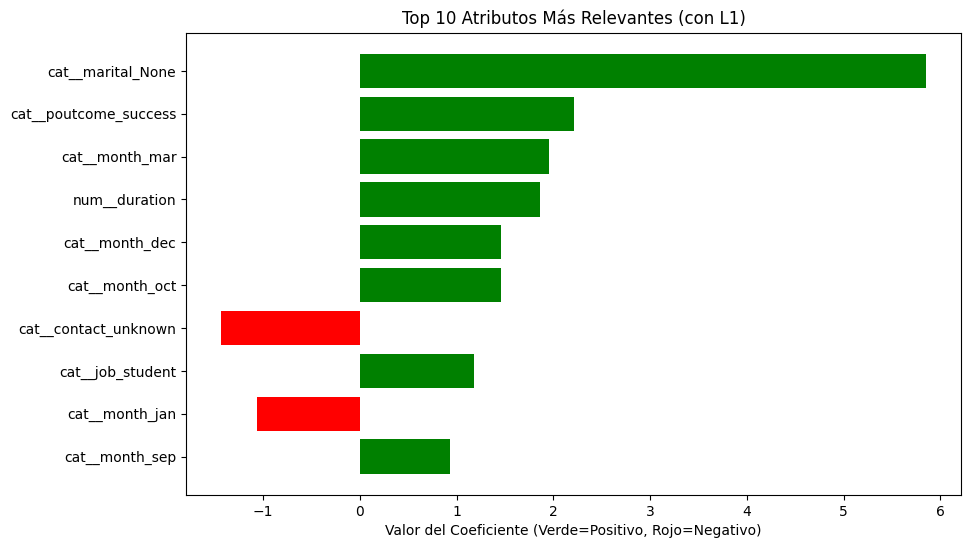

In [136]:
# Extraemos el mejor modelo lineal L1 del GridSearchCV
mejor_modelo_lineal = grid_lineal_l1.best_estimator_

# Extraemos los nombres de las variables despues del preprocesado
nombres_variables = mejor_modelo_lineal.named_steps['preprocesador'].get_feature_names_out()

# Extraemos los coeficientes que le ha asignado el modelo lineal
coeficientes = mejor_modelo_lineal.named_steps['lineal_l1'].coef_[0]

# Creamos un dataframe para verlo mejor y lo ordenamos por valor absoluto
df_importancias = pd.DataFrame({'Variable': nombres_variables, 'Coeficiente': coeficientes})
df_importancias['Importancia_Absoluta'] = df_importancias['Coeficiente'].abs()
df_importancias = df_importancias.sort_values(by='Importancia_Absoluta', ascending=False)

# Imprimimos el Top 10 de variables que más deciden si alguien contrata o no
print("Top 10 variables más relevantes (según el Modelo Lineal L1):")
print(df_importancias.head(10)[['Variable', 'Coeficiente']])

# Las dibujamos
plt.figure(figsize=(10, 6))
top_10 = df_importancias.head(10)
colores = ['green' if c > 0 else 'red' for c in top_10['Coeficiente']]

plt.barh(top_10['Variable'][::-1], top_10['Coeficiente'][::-1], color=colores[::-1])
plt.title('Top 10 Atributos Más Relevantes (con L1)')
plt.xlabel('Valor del Coeficiente (Verde=Positivo, Rojo=Negativo)')
plt.show()

Al observar los coeficientes, podmeos extraer los atributos más relevantes. Los que más impulsan la contratación vendrían a ser poutcome_success, duration y una gran cantidad de meses del atributo month. (en especial month_mar).

Con marital pasa algo curioso, ya que podemos ver como marital_None tiene un peso muy alto, sin embargo no vemos su contraparte en la tabla. Esto nos podría indicar que se trata de un grupo pequeño que contiene marital_None y casualmente todos tienen como etiqueta el valor positivo. Por esto mismo, no lo considero dentro de la lista de atributos más relevantes.

Por otro lado, los que más penalizan la contratación serían contact_unknown y month_jan.


#Resultados y Modelo final
Tras finalizar el punto anterior, podemos apreciar que el modelo SVM obtiene los mejores resultados, logrando una accuracy de 0.8589 frente a la puntuación de 0.8328 del modelo lineal con L1, 0.8086 de KNN y 0.7271 de árboles de decisión.

A continuación mostramos una gráfica para respresentar visualmente la diferencia de todos los modelos estudiados:

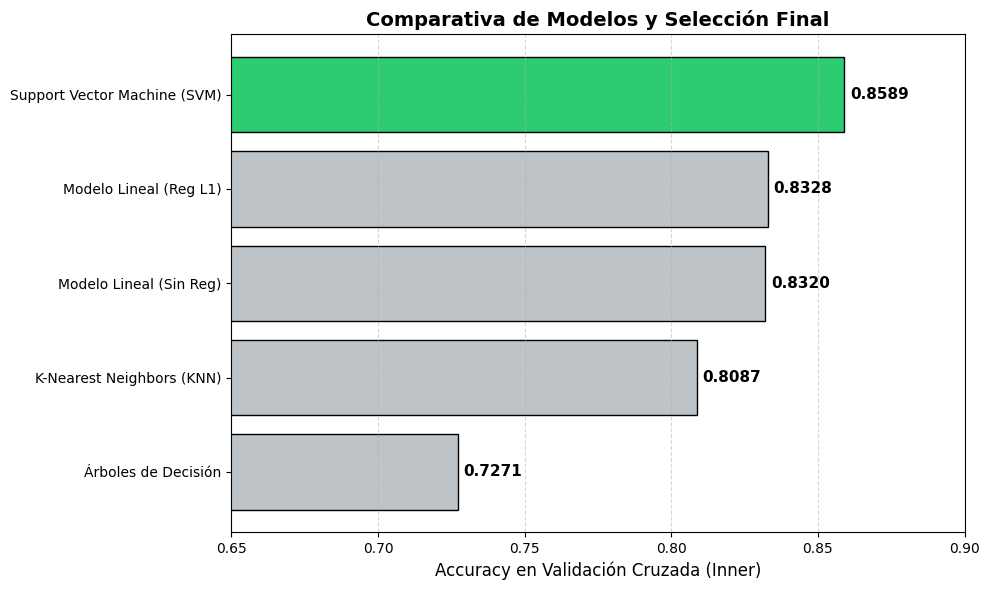

In [137]:
#Datos de nuestros modelos (ordenados de peor a mejor para que el mejor quede arriba en el gráfico)
modelos = ['Árboles de Decisión', 'K-Nearest Neighbors (KNN)', 'Modelo Lineal (Sin Reg)', 'Modelo Lineal (Reg L1)', 'Support Vector Machine (SVM)']
accuracies = [grid_arbol.best_score_, buscador_grid_knn.best_score_, res_lineal_none.mean(), grid_lineal_l1.best_score_, grid_svm.best_score_]

#Creamos el gráfico
fig, ax = plt.subplots(figsize=(10, 6))

#Asignamos colores: verde para el ganador (svm) y gris para elr esto
colores = ['#bdc3c7', '#bdc3c7', '#bdc3c7', '#bdc3c7', '#2ecc71']

#Dibujamos las barras horizontales
barras = ax.barh(modelos, accuracies, color=colores, edgecolor='black')

#Añadimos el valor numérico exacto a la derecha de cada barra
for barra in barras:
    ancho = barra.get_width()
    ax.text(
        ancho + 0.002, # Posición X (un poquito a la derecha de la barra)
        barra.get_y() + barra.get_height()/2, # Posición Y (centro de la barra)
        f'{ancho:.4f}', # Texto a mostrar (el accuracy)
        va='center',
        fontsize=11,
        fontweight='bold'
    )

#Ajustamos los ejes y añadimos títulos
ax.set_xlim(0.65, 0.90)
ax.set_xlabel('Accuracy en Validación Cruzada (Inner)', fontsize=12)
ax.set_title('Comparativa de Modelos y Selección Final', fontsize=14, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Viendo de esta manera más clara las diferencias existentes entre las accuracy de los distintos modelos, nos decantamos por un modelo SVM cono nuestro modelo final, ya que, pese a ser algo más lento aún con los hiperparámetros ya fijados, consideramos la diferencia de tiempo existente insuficiente para elegir otro modelo (como el modelo lineal con L1) por encima de SVM al ser nuestro objetivo maximizar la capacidad de generalización y acierto.

##Evaluación outer del modelo
Ahora entrenaremos el modelo SVM ganador, le pasaremos los datos de test para ver su rendimiento real y dibujaremos la matriz de confusión, guardando finalmente el resultado en un archivo .pkl.

 --- EVALUACIÓN FINAL --- 

Accuracy de Evaluación Outer (Test): 0.8234



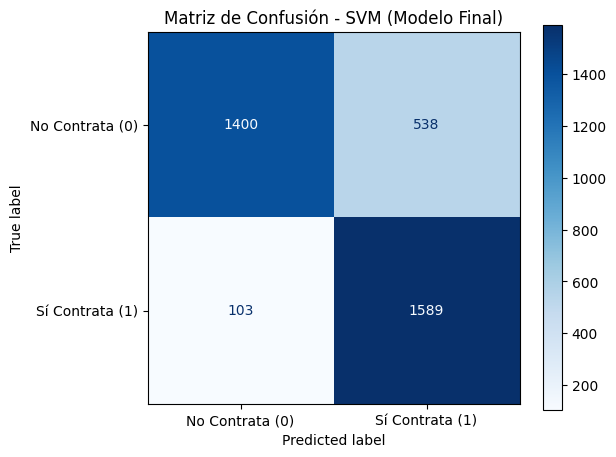


Modelo guardado exitosamente como 'modelo_final.pkl'


In [138]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import joblib

#Definimos y entrenamos el modelo final ------------------

#Construimos el pipeline definitivo con los hiperparámetros óptimos que encontramos
pipeline_final = Pipeline([
    ('preprocesador', preprocesador_definitivo),
    ('svm', SVC(C=1, gamma=0.1, kernel='rbf', random_state=SEMILLA, probability= True))
])

#Entrenamos el modelo con nuestros datos de entrenamiento
pipeline_final.fit(x_train, y_train_num)


#Evaluación Outer (Estimación de desempeño futuro) ------------------
print(" --- EVALUACIÓN FINAL --- \n")

#Predecimos sobre el conjunto de test
y_test_pred = pipeline_final.predict(x_test)

#Calculamos el accuracy real
accuracy_outer = accuracy_score(y_test_num, y_test_pred)
print(f"Accuracy de Evaluación Outer (Test): {accuracy_outer:.4f}\n")


#Matriz de Confusión ------------------

cm = confusion_matrix(y_test_num, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Contrata (0)', 'Sí Contrata (1)'])

#Dibujamos la matriz
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Matriz de Confusión - SVM (Modelo Final)")
plt.show()


#Guardamos el modelo en un fichero ------------------

joblib.dump(pipeline_final, 'modelo_final.pkl')
print("\nModelo guardado exitosamente como 'modelo_final.pkl'")

#Tarea de elección abierta - Ensembles

##Stacking

Como tarea de elección abierta, y para aprovechar todo el trabajo realizado anteriormente con los distintos modelos, implementaré un ensamblador 'stacking'. En lugar de evaluar un modelo aislado como el Random Forest, se ha optado por implementar la técnica de Stacking, ya que con este tipo de ensamblador podremos hacer uso de todos los modelos entrenados de los que ya conocemos sus hiperparámetros ideales.

En este caso nuestros modelos base serán los modelos de KNN, árboles de decisión y SVM, dejando que el modelo lineal actúe como organizador por encima. Usaremos los mejores hiperparámetros previamente estudiados para cada uno para obtener el mejor resultado.

Una vez definido el clasificador, usaremos una pipeline en la que agregaremos también el preprocesador que llevamos usando desde el principio y lo evaluaremos (evaluación inner) con validación cruzada para compararlo con el el que tuvo mejor resultado anteriormente: nuestro modelo final SVM.

Resultado (inner) del modelo stacking ensemble: 0.8579375848032565
Tiempo de entrenamiento: 44.59 s


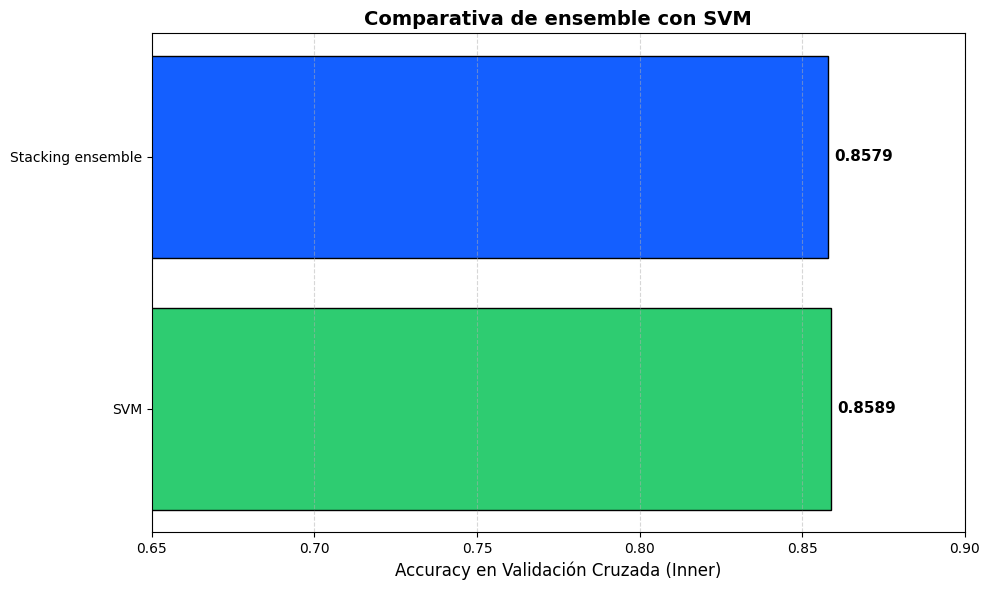

In [139]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier

# Definimos los Modelos Base con los mejores hiperparámetros descubiertos
modelo_svm = SVC(C=1, gamma=0.1, kernel='rbf', random_state=SEMILLA, probability=True)
modelo_knn = KNeighborsClassifier(n_neighbors=16, weights='distance', p=2)
# (Como el hiperparámetro min_sample_split no afectaba a nuestro modelo lo omitiremos)
modelo_arbol = tree.DecisionTreeClassifier(max_depth=14, min_impurity_decrease=0.001, random_state=SEMILLA)

# Creamos la lista de estimadores
estimadores_base = [
    ('svm', modelo_svm),
    ('knn', modelo_knn),
    ('tree', modelo_arbol)
]

# Definimos el meta-modelo jefe usando regresión logística.
# Usaremos un modelo lineal con L1 y C=1)
meta_modelo = LogisticRegression(penalty='l1', solver='liblinear', C=1, random_state=SEMILLA)

# Construimos el StackingClassifier
stacking_clf = StackingClassifier(
    estimators = estimadores_base,
    final_estimator = meta_modelo,
    cv=5
)

# Lo metemos todo en un pipeline con el preprocesador_definitivo
pipeline_stacking = Pipeline([
    ('preprocesador', preprocesador_definitivo),
    ('stacking', stacking_clf)
])

# Hacemos inner evaluation con validación cruzada para compararlo de forma justa
res_stacking = cross_val_score(pipeline_stacking, x_train, y_train_num, cv=kf, scoring='accuracy', n_jobs=-1)

print("Resultado (inner) del modelo stacking ensemble:", res_stacking.mean())

inicio = time.time()
pipeline_stacking.fit(x_train, y_train_num)
fin = time.time()

print(f"Tiempo de entrenamiento: {fin - inicio:.2f} s")

# Hacemos una comparación en gráfica

modelos = ['SVM', 'Stacking ensemble']
accuracies = [grid_svm.best_score_, res_stacking.mean()]

fig, ax = plt.subplots(figsize=(10, 6))
colores = ['#2ecc71', '#145fff']
barras = ax.barh(modelos, accuracies, color=colores, edgecolor='black')

#Añadimos el valor numérico exacto a la derecha de cada barra
for barra in barras:
    ancho = barra.get_width()
    ax.text(
        ancho + 0.002, # Posición X (un poquito a la derecha de la barra)
        barra.get_y() + barra.get_height()/2, # Posición Y (centro de la barra)
        f'{ancho:.4f}', # Texto a mostrar (el accuracy)
        va='center',
        fontsize=11,
        fontweight='bold'
    )

#Ajustamos los ejes y añadimos títulos
ax.set_xlim(0.65, 0.90)
ax.set_xlabel('Accuracy en Validación Cruzada (Inner)', fontsize=12)
ax.set_title('Comparativa de ensemble con SVM', fontsize=14, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Como podemos ver, SVM sigue siendo superior incluso a nuestro stacking ensemble.

Por ultimo, realizaremos una última evaluación OUTER para ver cómo es capaz de evaluar el conjunto test y lo compararemos con nuestro modelo final SVM.

Accuracy de Evaluación Outer (Test) del stacking ensemble: 0.8452


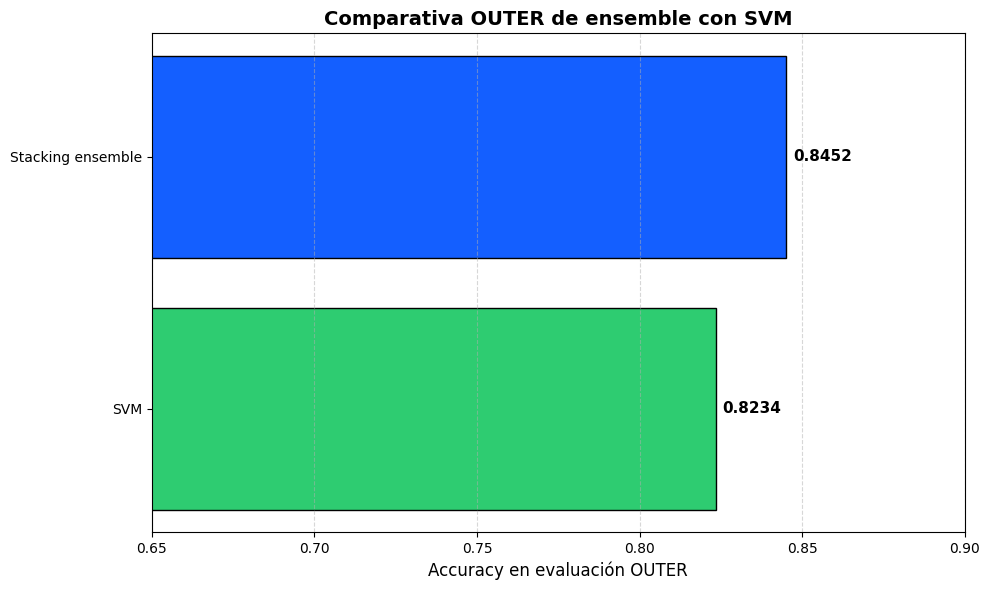

In [140]:
from sklearn import metrics

# Hacemos ahora outer evaluation
y_test_pred_stacking = pipeline_stacking.predict(x_test)

# Calculamos el accuracy real
accuracy_outer_stacking = metrics.accuracy_score(y_test_num, y_test_pred_stacking)

print(f"Accuracy de Evaluación Outer (Test) del stacking ensemble: {accuracy_outer_stacking:.4f}")

# Hacemos una comparación en gráfica

modelos = ['SVM', 'Stacking ensemble']
accuracies = [accuracy_outer, accuracy_outer_stacking]

fig, ax = plt.subplots(figsize=(10, 6))
colores = ['#2ecc71', '#145fff']
barras = ax.barh(modelos, accuracies, color=colores, edgecolor='black')

#Añadimos el valor numérico exacto a la derecha de cada barra
for barra in barras:
    ancho = barra.get_width()
    ax.text(
        ancho + 0.002, # Posición X (un poquito a la derecha de la barra)
        barra.get_y() + barra.get_height()/2, # Posición Y (centro de la barra)
        f'{ancho:.4f}', # Texto a mostrar (el accuracy)
        va='center',
        fontsize=11,
        fontweight='bold'
    )

#Ajustamos los ejes y añadimos títulos
ax.set_xlim(0.65, 0.90)
ax.set_xlabel('Accuracy en evaluación OUTER', fontsize=12)
ax.set_title('Comparativa OUTER de ensemble con SVM', fontsize=14, fontweight='bold')
ax.grid(True, axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Finalmente, con la evaluación outer se obtiene una bastante mejor accuracy en nuestro stacking ensemble que en nuestro modelo final SVM, aumentando la misma en más de un 2% de aciertos (de 0.8234 SVM a 0.8452 ensemble). Aunque la SVM parecía superior en la validación cruzada, el modelo Stacking Ensemble demuestra una capacidad de generalización superior ante datos no vistos, demostrando su capacidad de lograr un menor sobreajuste.

Aunque para cumplir con los requisitos de la práctica mantendremos la SVM como modelo final, realmente Ensemble un mejor candidato.

# Declaración de uso de IA
Declaramos haber hecho uso de la IA generativa Gemini 3.1 para facilitarnos la búsqueda y uso de funciones y bibliotecas usadas para la generación de gráficas y plots, así como para entender y comprender las bibliotecas de los métodos avanzados para los cuales no disponíamos de sesiones del laboratorio. Adicionalmente hicimos uso de ellas para ayudarnos a modificar el código de ejemplo dado de Streamlit para nuestro modelo.

También hemos hecho uso de la propia IA incluida en Google Colab (Gemini 2.5 Flash) para que nos ayude a comprender y solventar los errores que ibamos encontrando.
